# Fitting scores with ML model

### First we try to learn a ML model to fit scores to predict best variants following a simple deterministic model

In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from sequence_classes import protocol, calculate_scores, T_sel, T_viab
from analysis import pearson, precision_at_k

## 1. Building a simple deterministic model for variants performance.

Variants are represented by the sequence of 7 amino-acids that are among a list of 20 different amino-acids.
We will define some arbitrary rules to express a better viability and a better selectivity.
Then the model will just face the results and will try to fit the scores for viability and selectivity (cf full_DE_loopV1.ipynb).

In [2]:
key = jax.random.key(42)
key_seq, key_viab_w, key_sel_w, key_n0, key_run = jax.random.split(key, 5)

num_sequences   = 1000000
num_positions   = 7     # L
num_amino_acids = 20

# Random library: sequences and initial read counts
sequences = jax.random.randint(
    key_seq, shape=(num_sequences, num_positions),
    minval=0, maxval=num_amino_acids
)

""" 
Before the weights that define the model were randomized, we are going to build these matrices to help some variants
"""
# Two independent score matrices
# viability_weights   = jax.random.normal(key_viab_w, shape=(num_amino_acids, num_positions))
# selectivity_weights = jax.random.normal(key_sel_w,  shape=(num_amino_acids, num_positions))

n0 = jax.random.randint(
    key_n0, shape=(num_sequences,), minval=10, maxval=1000
).astype(jnp.float32)

print(f"Library: {num_sequences} sequences of length {num_positions}")
print(f"First sequences:\n{sequences[:3]}")


Library: 1000000 sequences of length 7
First sequences:
[[ 4 11 19  1 10 19  0]
 [ 9  8 11 16  1  2  7]
 [11  4 19  7  3 19 13]]


### Building the weights matrices

**GT = ground truth**

Shape: `(num_amino_acids, num_positions)` = 20 × 7.  
AA indices 0–19, positions 0–6.

Weights are kept small so scores stay in **[-10, +10]** → safe range for `exp(score/T)` with T ≥ 0.5.

---

#### Viability rules
1. **Even-row AAs preferred** — AA 0,2,4,...,18 get +0.5 at every position
2. **Diagonal affinity** — AA i at position i gets +1.0 (positional specificity)
3. **High-index AAs bad at position 0** — AA 15–19 get -1.0 at position 0
4. **Low-index AAs bad at last position** — AA 0–4 get -0.7 at position 6
5. **Central position favours mid-range AAs** — AA 10–12 get +0.7 at position 3

Expected score range: **[-5, +10]**

---

#### Selectivity rules
1. **High-index AAs universally selective** — AA 15–19 get +0.5 at every position
2. **N-terminus specificity** — AA 5–9 get +0.7 at position 0 only
3. **C-terminal binding motif** — AA 0–1 get +1.0 at positions 4 and 5
4. **Central penalty** — AA 8–12 get -0.7 at position 2
5. **Distal positions amplified** — columns 5 and 6 scaled ×1.2
6. **Universally bad AAs** — AA 13–14 get -0.3 everywhere

Expected score range: **[-5, +6]**


In [3]:
# ── Viability weights (20 × 7) ──────────────────────────────────────────────
# Weights kept small: scores should stay in [-10, +10]
w_viab = np.zeros((num_amino_acids, num_positions))

# Rule 1: even-indexed AAs preferred at all positions
w_viab[0::2, :] += 0.5

# Rule 2: AA i likes position i (diagonal affinity)
for i in range(num_positions):
    w_viab[i, i] += 1.0

# Rule 3: AA 15-19 bad at position 0 (N-terminus)
w_viab[15:20, 0] -= 1.0

# Rule 4: AA 0-4 bad at position 6 (C-terminus)
w_viab[0:5, 6] -= 0.7

# Rule 5: AA 10-12 good at center position 3
w_viab[10:13, 3] += 0.7

viability_weights_GT = jnp.array(w_viab)

print(f"Viability weights GT — min={w_viab.min():.2f}  max={w_viab.max():.2f}")
print(f"Expected score range after calculate_scores: see cell below")


Viability weights GT — min=-1.00  max=1.50
Expected score range after calculate_scores: see cell below


In [4]:
# ── Selectivity weights (20 × 7) ────────────────────────────────────────────
# Weights kept small: scores should stay in [-5, +6]
w_sel = np.zeros((num_amino_acids, num_positions))

# Rule 1: AA 15-19 preferred at all positions
w_sel[15:20, :] += 0.5

# Rule 2: AA 5-9 favoured at position 0 only (N-terminus specificity)
w_sel[5:10, 0] += 0.7

# Rule 3: AA 0-1 strongly favoured at positions 4-5 (binding motif)
w_sel[0:2, 4:6] += 1.0

# Rule 4: AA 8-12 penalised at position 2 (steric clash)
w_sel[8:13, 2] -= 0.7

# Rule 5: positions 5 and 6 slightly amplified (exposed tip)
w_sel[:, 5] *= 1.2
w_sel[:, 6] *= 1.2

# Rule 6: AA 13-14 universally bad
w_sel[13:15, :] -= 0.3

selectivity_weights_GT = jnp.array(w_sel)

print(f"Selectivity weights GT — min={w_sel.min():.2f}  max={w_sel.max():.2f}")

# Sanity check: score range on actual sequences
from sequence_classes import calculate_scores
v_scores = calculate_scores(sequences, viability_weights_GT)
s_scores = calculate_scores(sequences, selectivity_weights_GT)
print(f"Viability scores   — min={float(v_scores.min()):.2f}  max={float(v_scores.max()):.2f}")
print(f"Selectivity scores — min={float(s_scores.min()):.2f}  max={float(s_scores.max()):.2f}")
print(f"exp(v_max/T_viab=1.0) = {float(jnp.exp(v_scores.max())):.2e}  (float32 max ~3.4e38)")
print(f"exp(s_max/T_sel=0.5)  = {float(jnp.exp(s_scores.max() / 0.5)):.2e}")


Selectivity weights GT — min=-0.70  max=1.20
Viability scores   — min=-1.70  max=8.20
Selectivity scores — min=-2.20  max=5.00
exp(v_max/T_viab=1.0) = 3.64e+03  (float32 max ~3.4e38)
exp(s_max/T_sel=0.5)  = 2.20e+04


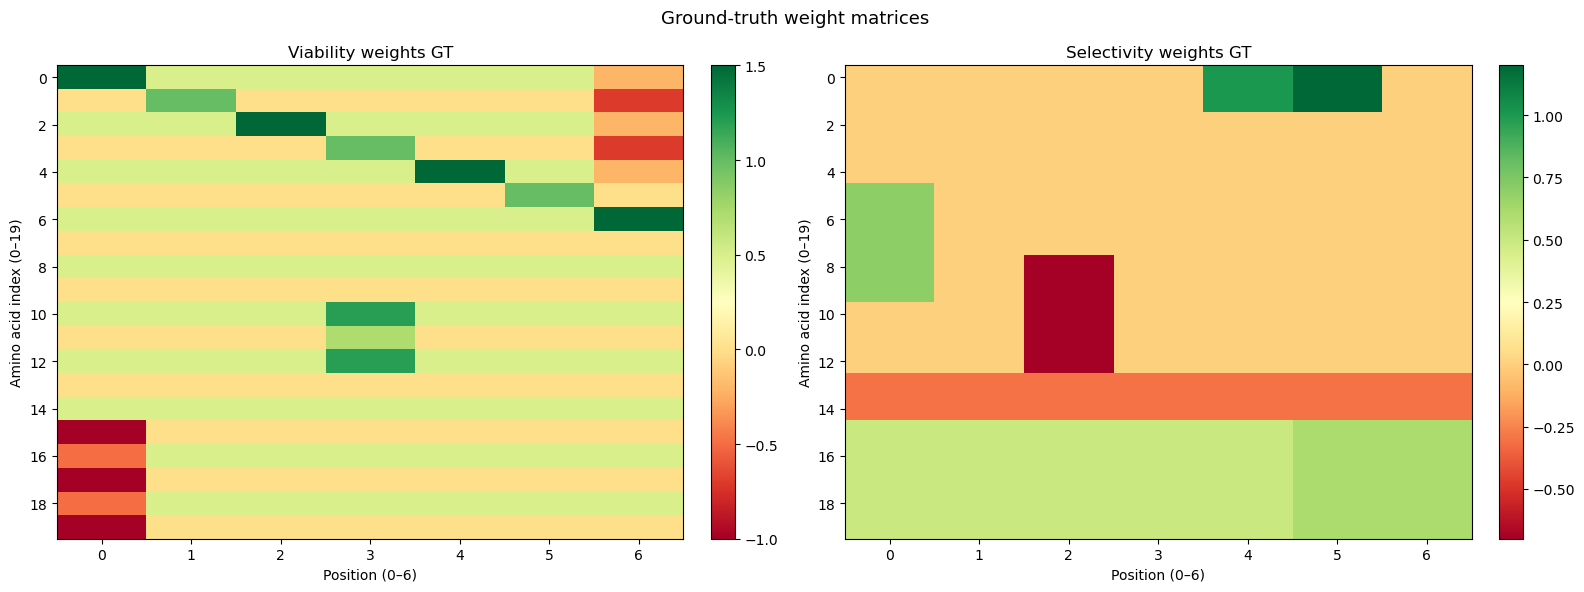

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, w, title, cmap in [
    (axes[0], viability_weights_GT,   'Viability weights GT',   'RdYlGn'),
    (axes[1], selectivity_weights_GT, 'Selectivity weights GT', 'RdYlGn'),
]:
    im = ax.imshow(np.array(w), cmap=cmap, aspect='auto',
                   vmin=float(w.min()), vmax=float(w.max()))
    ax.set_xlabel('Position (0–6)'); ax.set_ylabel('Amino acid index (0–19)')
    ax.set_xticks(range(num_positions))
    ax.set_yticks(range(0, num_amino_acids, 2))
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Ground-truth weight matrices', fontsize=13)
plt.tight_layout()
plt.show()


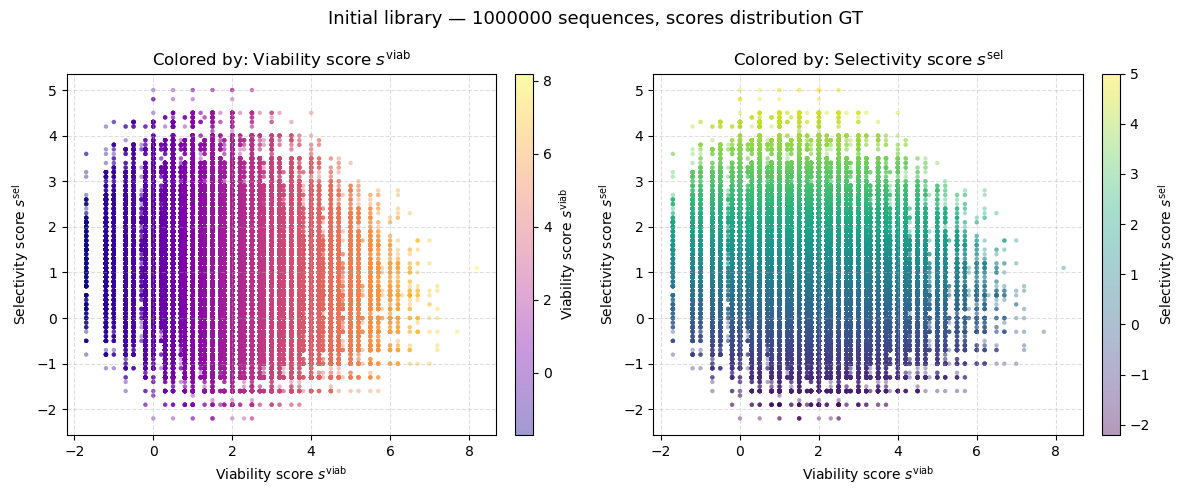

In [6]:
# Compute scores from initial library
viability_scores   = calculate_scores(sequences, viability_weights_GT)
selectivity_scores = calculate_scores(sequences, selectivity_weights_GT)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, color_scores, cmap, label in [
    (axes[0], viability_scores,   'plasma',  r'Viability score $s^{\mathrm{viab}}$'),
    (axes[1], selectivity_scores, 'viridis', r'Selectivity score $s^{\mathrm{sel}}$'),
]:
    sc = ax.scatter(viability_scores, selectivity_scores,
                    c=color_scores, cmap=cmap, alpha=0.4, edgecolors='none', s=10)
    plt.colorbar(sc, ax=ax, label=label, fraction=0.046, pad=0.04)
    ax.set_xlabel(r'Viability score $s^{\mathrm{viab}}$')
    ax.set_ylabel(r'Selectivity score $s^{\mathrm{sel}}$')
    ax.set_title(f'Colored by: {label}')
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle(f'Initial library — {num_sequences} sequences, scores distribution GT', fontsize=13)
plt.tight_layout()
plt.show()

In [7]:
_, capsids, lambda1p, n2 = protocol(
    n0, sequences,
    viability_weights_GT,
    selectivity_weights_GT,
    use_full_ngs=False
)

print(f"n0      : {n0[:5]}  non-zero={int(jnp.sum(n0 > 0))}")
print(f"capsids : {capsids[:5]}  non-zero={int(jnp.sum(capsids > 0))}")
print(f"lambda1p: {lambda1p[:5]}  non-zero={int(jnp.sum(lambda1p > 0))}")
print(f"n2      : {n2[:5]}  non-zero={int(jnp.sum(n2 > 0))}")


n0      : [656. 194. 775. 846. 285.]  non-zero=1000000
capsids : [0. 0. 0. 1. 0.]  non-zero=23706
lambda1p: [0. 0. 0. 0. 0.]  non-zero=12763
n2      : [0. 0. 0. 0. 0.]  non-zero=5622


In [8]:
# Debug: trace what's happening before n2
viability_scores_gt   = calculate_scores(sequences, viability_weights_GT)
selectivity_scores_gt = calculate_scores(sequences, selectivity_weights_GT)

print(f"viability_scores   : min={float(viability_scores_gt.min()):.2f}  max={float(viability_scores_gt.max()):.2f}")
print(f"selectivity_scores : min={float(selectivity_scores_gt.min()):.2f}  max={float(selectivity_scores_gt.max()):.2f}")

exp_sel = jnp.exp(selectivity_scores_gt / 0.5)
print(f"exp(s_sel/T_sel)   : min={float(exp_sel.min()):.2e}  max={float(exp_sel.max()):.2e}  any_inf={bool(jnp.any(jnp.isinf(exp_sel)))}")

post = lambda1p * exp_sel
print(f"post_select        : sum={float(jnp.sum(post)):.2e}  any_nan={bool(jnp.any(jnp.isnan(post)))}  any_inf={bool(jnp.any(jnp.isinf(post)))}")
print(f"n2_prime           : any_nan={bool(jnp.any(jnp.isnan(post / jnp.sum(post))))}")


viability_scores   : min=-1.70  max=8.20
selectivity_scores : min=-2.20  max=5.00
exp(s_sel/T_sel)   : min=1.23e-02  max=2.20e+04  any_inf=False
post_select        : sum=1.37e+06  any_nan=False  any_inf=False
n2_prime           : any_nan=False


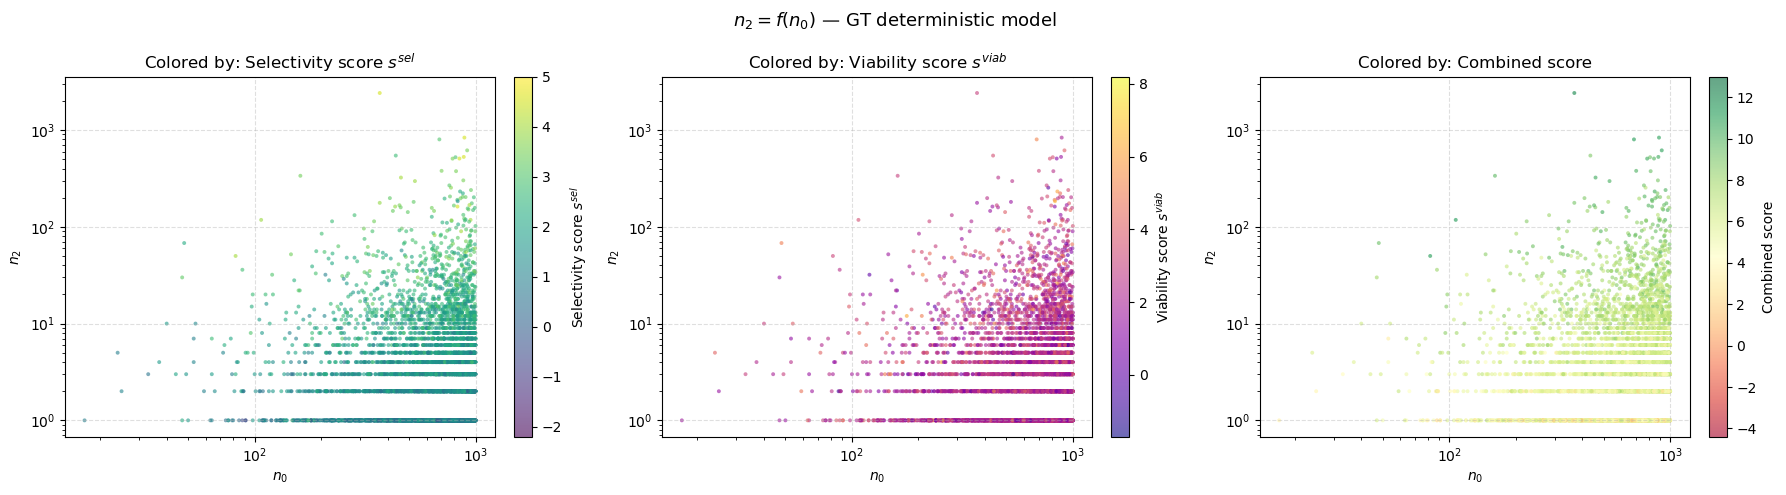

In [9]:
combined_scores = viability_scores_gt / T_viab + selectivity_scores_gt / T_sel

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sel_min,  sel_max  = float(selectivity_scores_gt.min()), float(selectivity_scores_gt.max())
viab_min, viab_max = float(viability_scores_gt.min()),   float(viability_scores_gt.max())
comb_min, comb_max = float(combined_scores.min()),    float(combined_scores.max())

mask = (n0 > 0) & (n2 > 0)

for ax, color_scores, vmin, vmax, cmap, label in [
    (axes[0], selectivity_scores_gt, sel_min,  sel_max,  'viridis', r'Selectivity score $s^{sel}$'),
    (axes[1], viability_scores_gt,   viab_min, viab_max, 'plasma',  r'Viability score $s^{viab}$'),
    (axes[2], combined_scores,    comb_min, comb_max, 'RdYlGn',  r'Combined score'),
]:
    sc = ax.scatter(n0[mask], n2[mask], c=color_scores[mask],
                    cmap=cmap, alpha=0.6, s=8, edgecolors='none',
                    vmin=vmin, vmax=vmax)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel(r'$n_0$'); ax.set_ylabel(r'$n_2$')
    ax.set_title(f'Colored by: {label}')
    ax.grid(True, linestyle='--', alpha=0.4)
    plt.colorbar(sc, ax=ax, label=label, fraction=0.046, pad=0.04)

plt.suptitle(r'$n_2 = f(n_0)$ — GT deterministic model', fontsize=13)
plt.tight_layout()
plt.show()


## 2. Linear regression — recovering viability and selectivity weights

**Step 1** — compute log-ratio targets from observables (n0, λ1', n2) :

$$y^{\text{viab}}(s) = \log\frac{\lambda_1'(s)}{\hat{n}_0(s)}, \qquad y^{\text{sel}}(s) = \log\frac{n_2(s)}{\hat{\lambda}_1'(s)}$$

**Step 2** — fit a linear model `f(seq) = Σ w[a_i, i]` (140 parameters) via OLS on all observed sequences.

**Step 3** — compare learned weights to ground truth.


In [10]:
eps = 0.5   # pseudocount to handle zeros

n0_norm  = n0       / jnp.sum(n0)       * jnp.sum(lambda1p)
l1p_norm = lambda1p / jnp.sum(lambda1p) * jnp.sum(n2)

y_viab = jnp.log((lambda1p + eps) / (n0_norm + eps))
y_sel  = jnp.log((n2 + eps) / (l1p_norm + eps))

print(f"y_viab : min={float(y_viab.min()):.2f}  max={float(y_viab.max()):.2f}")
print(f"y_sel  : min={float(y_sel.min()):.2f}  max={float(y_sel.max()):.2f}")

y_viab : min=-0.18  max=5.93
y_sel  : min=-4.92  max=6.32


### One-hot encoding & model fitting

In [11]:
X_oh   = jax.nn.one_hot(sequences, num_amino_acids)
X_flat = np.array(X_oh.reshape(num_sequences, -1))
X_bias = np.hstack([X_flat, np.ones((num_sequences, 1))])


def fit_weights_ridge(X, y, T, lam=1.0):
    """Ridge: w = (XᵀX + λI)⁻¹ Xᵀy

    Penalises large weights → shrinks noise-induced non-zeros toward 0.
    The bias column is excluded from the penalty (standard practice).
    lam: regularisation strength. Larger = more shrinkage.
    """
    Xw = X[:, :-1]
    n_params = Xw.shape[1]
    penalty  = np.zeros((n_params + 1, n_params + 1))
    penalty[:n_params, :n_params] = lam * np.eye(n_params)
    XtX = X.T @ X + penalty
    Xty = X.T @ np.array(y)
    coef = np.linalg.solve(XtX, Xty)
    w = coef[:-1].reshape(num_positions, num_amino_acids).T
    return jnp.array(w * T)

v_gt = calculate_scores(sequences, viability_weights_GT)
s_gt = calculate_scores(sequences, selectivity_weights_GT)


### Why OLS is not used

**Structural rank deficiency.**  
The one-hot design matrix $X \in \mathbb{R}^{N \times 141}$ has 7 built-in linear dependencies: at each of the 7 positions, the 20 amino-acid indicator columns sum exactly to the bias column. The Gram matrix $X^\top X$ is therefore rank-134 instead of 141. The normal equations $X^\top X\,\hat{w} = X^\top y$ have infinitely many solutions; the minimum-norm one is not guaranteed to align with the true weights.

**Noise dominance.**  
With $N = 10^6$ sequences and sequencing depth $D = 50\,000$, roughly 95 % of variants receive zero counts at the viability stage ($\lambda_1' = 0$). For those sequences the log-ratio target reduces to $y_\text{viab} = \log(\varepsilon\,/\,n_{0,\text{norm}})$, which is pure sampling noise with no viability information. OLS, having no regularisation, attempts to fit this noise across all $N$ samples; the recovered weights end up near zero with Pearson $r \approx 0$ against the ground truth.

**Ridge regression** resolves both issues: the $\lambda I$ term makes $X^\top X + \lambda I$ strictly positive definite (no singularity), and the penalty shrinks noise-driven coefficients toward zero, letting the small fraction of informative sequences ($\lambda_1' > 0$) drive the fit. The optimal $\lambda$ is selected by 5-fold cross-validation below.


### Cross-validation to find the best lambda

Séquences informatives — viabilité: 6464  sélectivité: 495
Best λ viabilité   : 1.805
Best λ sélectivité : 0.346


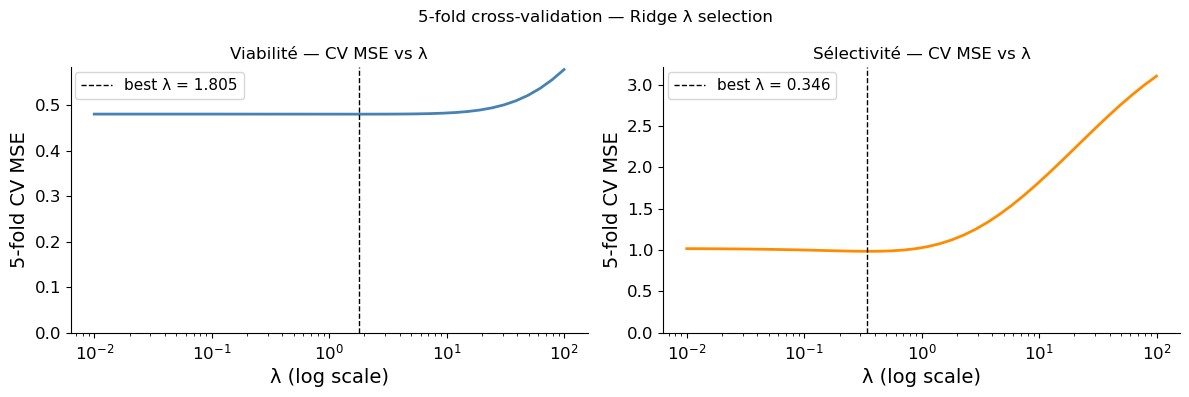


               Ridge (CV λ_viab=1.80, λ_sel=0.35)
  Viabilité   — r(scores):  0.9898
  Sélectivité — r(scores):  0.9122


In [25]:
from sklearn.model_selection import KFold

mask_viab = np.array(lambda1p > 0)   # séquences avec capsides détectées
mask_sel  = np.array(n2 > 0)         # séquences survivant à la sélection
print(f'Séquences informatives — viabilité: {mask_viab.sum()}  sélectivité: {mask_sel.sum()}')

X_viab = X_bias[mask_viab];  y_viab_m = np.array(y_viab)[mask_viab]
X_sel  = X_bias[mask_sel];   y_sel_m  = np.array(y_sel)[mask_sel]

K_FOLDS = 5
lambdas = np.logspace(-2, 2, 40)

kf = KFold(n_splits=K_FOLDS, shuffle=True, random_state=0)

def ridge_cv_mse(X, y, lambdas, kf):
    """
    Return the average CV MSE for each value of lambda
    """
    mse_all = np.zeros(len(lambdas))
    n_params = X.shape[1] - 1
    for i, lam_cv in enumerate(lambdas):
        penalty = np.zeros((X.shape[1], X.shape[1]))
        penalty[:n_params, :n_params] = lam_cv * np.eye(n_params)
        fold_mse = []
        for tr, val in kf.split(X):
            coef = np.linalg.solve(X[tr].T @ X[tr] + penalty, X[tr].T @ y[tr])
            fold_mse.append(np.mean((X[val] @ coef - y[val]) ** 2))
        mse_all[i] = np.mean(fold_mse)
    return mse_all

cv_mse_viab = ridge_cv_mse(X_viab, y_viab_m, lambdas, kf)
cv_mse_sel  = ridge_cv_mse(X_sel,  y_sel_m,  lambdas, kf)

lam_best_viab = lambdas[np.argmin(cv_mse_viab)]
lam_best_sel  = lambdas[np.argmin(cv_mse_sel)]
print(f'Best λ viabilité   : {lam_best_viab:.3f}')
print(f'Best λ sélectivité : {lam_best_sel:.3f}')

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, mse, lam_best, label, color in [
    (axes[0], cv_mse_viab, lam_best_viab, 'Viabilité',   'steelblue'),
    (axes[1], cv_mse_sel,  lam_best_sel,  'Sélectivité', 'darkorange'),
]:
    ax.semilogx(lambdas, mse, color=color, lw=2)
    ax.axvline(lam_best, color='k', linestyle='--', lw=1,
               label=f'best λ = {lam_best:.3f}')
    ax.set_xlabel('λ (log scale)', fontsize=14)
    ax.set_ylabel(f'{K_FOLDS}-fold CV MSE', fontsize=14)
    ax.set_title(f'{label} — CV MSE vs λ')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylim(bottom=0)
    ax.tick_params(labelsize=12)
    ax.legend(fontsize=11, borderaxespad=0.3)

plt.suptitle(f'{K_FOLDS}-fold cross-validation — Ridge λ selection', fontsize=12)
plt.tight_layout()
plt.show()

# ── Refit on all informative sequences with best λ ───────────────────────────
viability_weights_hat   = fit_weights_ridge(X_viab, y_viab_m, T_viab, lam=lam_best_viab)
selectivity_weights_hat = fit_weights_ridge(X_sel,  y_sel_m,  T_sel,  lam=lam_best_sel)

print()
print(f'               Ridge (CV λ_viab={lam_best_viab:.2f}, λ_sel={lam_best_sel:.2f})')
for label, w_hat, gt in [
    ('Viabilité   — r(scores)', viability_weights_hat,   v_gt),
    ('Sélectivité — r(scores)', selectivity_weights_hat, s_gt),
]:
    h = calculate_scores(sequences, w_hat)
    print(f'  {label}:  {pearson(h, gt):.4f}')


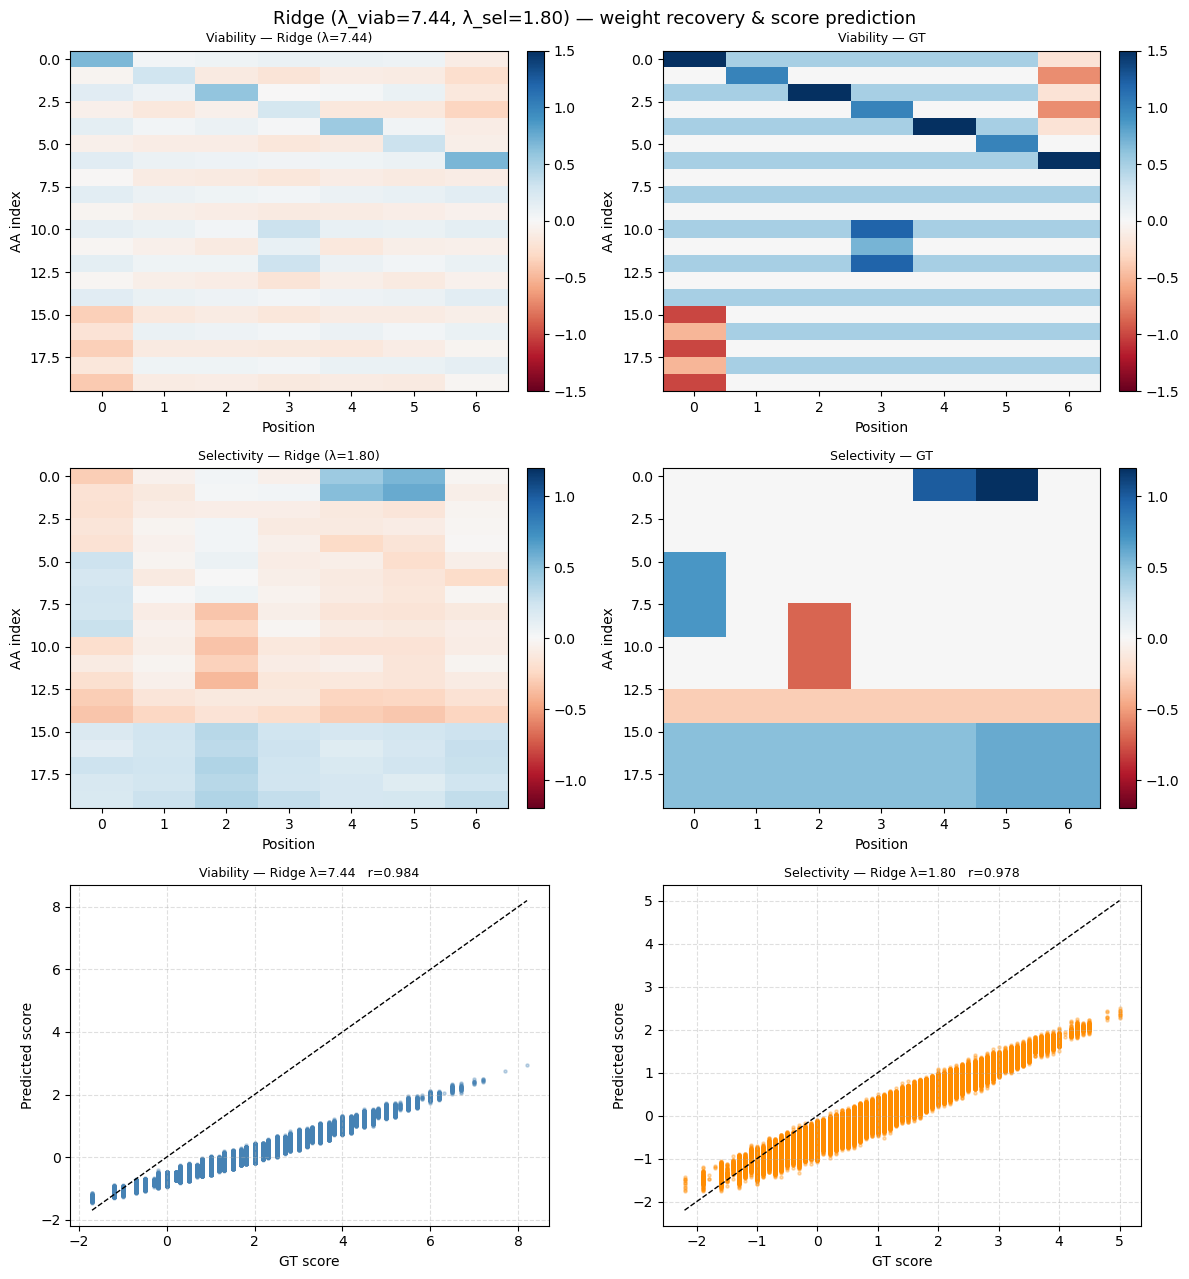

In [13]:
fig, axes = plt.subplots(3, 2, figsize=(12, 13))

# ── Rows 0-1: Ridge | GT weight matrices ─────────────────────────────────────
for row, (w_gt_m, w_hat, label, lam_row) in enumerate([
    (viability_weights_GT,   viability_weights_hat,   'Viability',   lam_best_viab),
    (selectivity_weights_GT, selectivity_weights_hat, 'Selectivity', lam_best_sel),
]):
    vmax = float(jnp.abs(jnp.stack([w_gt_m, w_hat])).max())
    for col, (data, title) in enumerate([
        (w_hat,  f'{label} — Ridge (λ={lam_row:.2f})'),
        (w_gt_m, f'{label} — GT'),
    ]):
        ax = axes[row, col]
        im = ax.imshow(np.array(data), cmap='RdBu', aspect='auto',
                       vmin=-vmax, vmax=vmax)
        ax.set_title(title, fontsize=9)
        ax.set_xlabel('Position'); ax.set_ylabel('AA index')
        ax.set_xticks(range(num_positions))
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# ── Row 2: score scatter Ridge vs GT ─────────────────────────────────────────
for col, (gt, w_hat, label, color, lam_row) in enumerate([
    (v_gt, viability_weights_hat,   'Viability',   'steelblue',  lam_best_viab),
    (s_gt, selectivity_weights_hat, 'Selectivity', 'darkorange', lam_best_sel),
]):
    ax = axes[2, col]
    hat = calculate_scores(sequences, w_hat)
    ax.scatter(gt, hat, alpha=0.3, s=5, color=color)
    lo = float(min(gt.min(), hat.min()))
    hi = float(max(gt.max(), hat.max()))
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
    r_val = pearson(gt, hat)
    ax.set_title(f'{label} — Ridge λ={lam_row:.2f}   r={r_val:.3f}', fontsize=9)
    ax.set_xlabel('GT score', fontsize=14); ax.set_ylabel('Predicted score', fontsize=14)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=12)

plt.suptitle(
    f'Ridge (λ_viab={lam_best_viab:.2f}, λ_sel={lam_best_sel:.2f}) — weight recovery & score prediction',
    fontsize=13)
plt.tight_layout()
plt.show()


### How does it perform? ie can the predicted model recover the top 20% of best variants?

  Top-%    Precision@k   (random baseline = top-%)
  ──────────────────────────────────────────────────
  Top   1%      0.666          (baseline: 0.010)
  Top   5%      0.736          (baseline: 0.050)
  Top  10%      0.774          (baseline: 0.100)
  Top  20%      0.815          (baseline: 0.200)


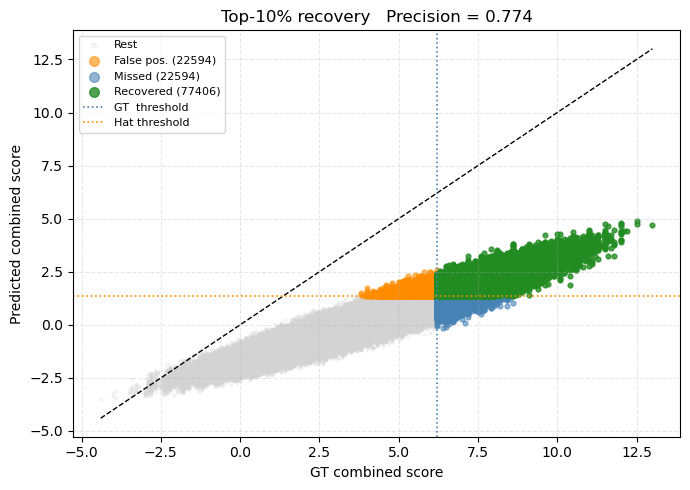

In [14]:
v_gt  = calculate_scores(sequences, viability_weights_GT)
s_gt  = calculate_scores(sequences, selectivity_weights_GT)
v_hat = calculate_scores(sequences, viability_weights_hat)
s_hat = calculate_scores(sequences, selectivity_weights_hat)

combined_gt  = v_gt  / T_viab + s_gt  / T_sel
combined_hat = v_hat / T_viab + s_hat / T_sel

fracs = [0.01, 0.05, 0.10, 0.20]
print(f'  Top-%    Precision@k   (random baseline = top-%)')
print(f'  ──────────────────────────────────────────────────')
for frac in fracs:
    p = precision_at_k(combined_gt, combined_hat, k_frac=frac)
    print(f'  Top {int(frac*100):3d}%      {p:.3f}          (baseline: {frac:.3f})')

# ── Visual: rank scatter + top-10% highlight ─────────────────────────────────
k10      = int(num_sequences * 0.10)
top_gt   = set(np.argsort(-np.array(combined_gt))[:k10])
top_hat  = set(np.argsort(-np.array(combined_hat))[:k10])
both     = np.array(sorted(top_gt & top_hat))      # recovered
only_gt  = np.array(sorted(top_gt  - top_hat))     # missed
only_hat = np.array(sorted(top_hat - top_gt))      # false positives
rest     = np.array(sorted(set(range(num_sequences)) - top_gt - top_hat))

cgt  = np.array(combined_gt)
chat = np.array(combined_hat)

fig, ax   = plt.subplots(1, 1, figsize=(7, 5))

# GT score vs predicted score, coloured by category
ax.scatter(cgt[rest],     chat[rest],     s=4,  alpha=0.2, color='lightgray',   label='Rest')
ax.scatter(cgt[only_hat], chat[only_hat], s=12, alpha=0.6, color='darkorange',  label=f'False pos. ({len(only_hat)})')
ax.scatter(cgt[only_gt],  chat[only_gt],  s=12, alpha=0.6, color='steelblue',   label=f'Missed ({len(only_gt)})')
ax.scatter(cgt[both],     chat[both],     s=12, alpha=0.8, color='forestgreen', label=f'Recovered ({len(both)})')
lo = float(min(cgt.min(), chat.min()))
hi = float(max(cgt.max(), chat.max()))
ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
# Thresholds
thr_gt  = float(np.sort(cgt)[-k10])
thr_hat = float(np.sort(chat)[-k10])
ax.axvline(thr_gt,  color='steelblue',  linestyle=':', lw=1.2, label=f'GT  threshold')
ax.axhline(thr_hat, color='darkorange', linestyle=':', lw=1.2, label=f'Hat threshold')
ax.set_xlabel('GT combined score', fontsize=14); ax.set_ylabel('Predicted combined score', fontsize=14)
ax.set_title(f'Top-10% recovery   Precision = {precision_at_k(combined_gt, combined_hat):.3f}')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(labelsize=12)
ax.legend(fontsize=10, markerscale=2, borderaxespad=0.3, borderpad=0.4, handlelength=1.2)



plt.tight_layout()
plt.show()


# Trying with random weights

In [15]:
viability_weights   = jax.random.normal(key_viab_w, shape=(num_amino_acids, num_positions))
selectivity_weights = jax.random.normal(key_sel_w,  shape=(num_amino_acids, num_positions))

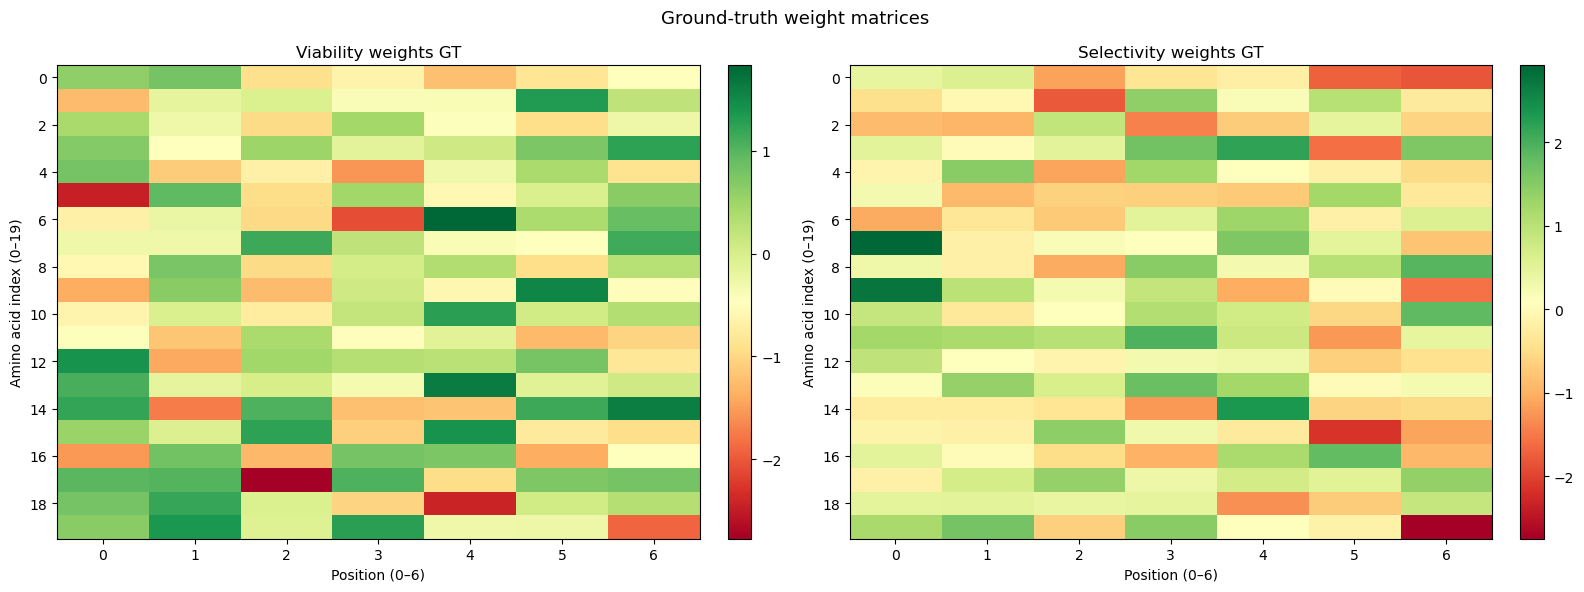

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, w, title, cmap in [
    (axes[0], viability_weights,   'Viability weights GT',   'RdYlGn'),
    (axes[1], selectivity_weights, 'Selectivity weights GT', 'RdYlGn'),
]:
    im = ax.imshow(np.array(w), cmap=cmap, aspect='auto',
                   vmin=float(w.min()), vmax=float(w.max()))
    ax.set_xlabel('Position (0–6)'); ax.set_ylabel('Amino acid index (0–19)')
    ax.set_xticks(range(num_positions))
    ax.set_yticks(range(0, num_amino_acids, 2))
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Ground-truth weight matrices', fontsize=13)
plt.tight_layout()
plt.show()


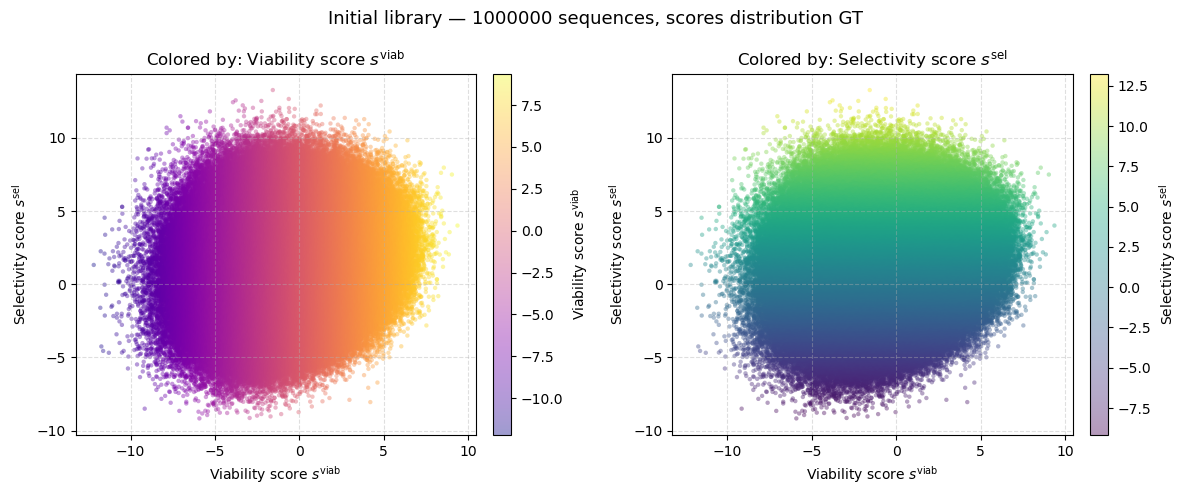

In [17]:
viability_scores   = calculate_scores(sequences, viability_weights)
selectivity_scores = calculate_scores(sequences, selectivity_weights)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, color_scores, cmap, label in [
    (axes[0], viability_scores,   'plasma',  r'Viability score $s^{\mathrm{viab}}$'),
    (axes[1], selectivity_scores, 'viridis', r'Selectivity score $s^{\mathrm{sel}}$'),
]:
    sc = ax.scatter(viability_scores, selectivity_scores,
                    c=color_scores, cmap=cmap, alpha=0.4, edgecolors='none', s=10)
    plt.colorbar(sc, ax=ax, label=label, fraction=0.046, pad=0.04)
    ax.set_xlabel(r'Viability score $s^{\mathrm{viab}}$')
    ax.set_ylabel(r'Selectivity score $s^{\mathrm{sel}}$')
    ax.set_title(f'Colored by: {label}')
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle(f'Initial library — {num_sequences} sequences, scores distribution GT', fontsize=13)
plt.tight_layout()
plt.show()

In [18]:
_, capsids, lambda1p, n2 = protocol(
    n0, sequences,
    viability_weights,
    selectivity_weights,
    use_full_ngs=False
)

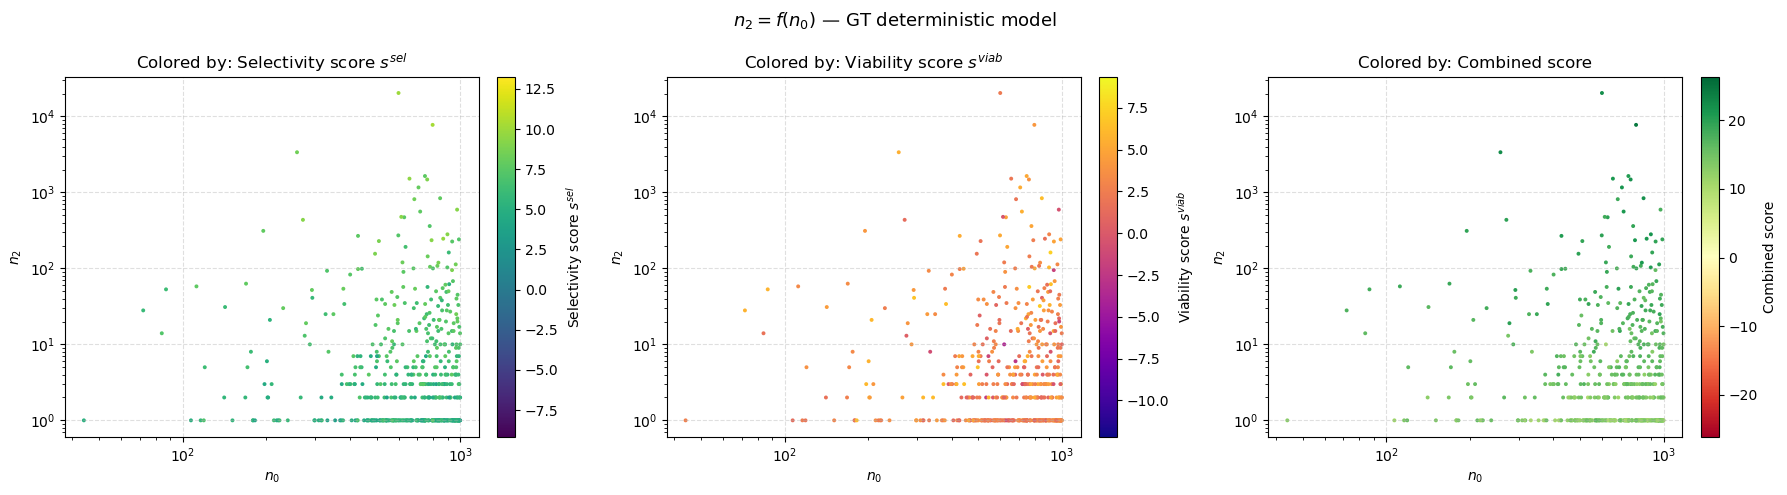

In [19]:
combined_scores = viability_scores / T_viab + selectivity_scores / T_sel

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sel_min,  sel_max  = float(selectivity_scores.min()), float(selectivity_scores.max())
viab_min, viab_max = float(viability_scores.min()),   float(viability_scores.max())
comb_min, comb_max = float(combined_scores.min()),    float(combined_scores.max())

mask = (n0 > 0) & (n2 > 0)

for ax, color_scores, vmin, vmax, cmap, label in [
    (axes[0], selectivity_scores, sel_min,  sel_max,  'viridis', r'Selectivity score $s^{sel}$'),
    (axes[1], viability_scores,   viab_min, viab_max, 'plasma',  r'Viability score $s^{viab}$'),
    (axes[2], combined_scores,    comb_min, comb_max, 'RdYlGn',  r'Combined score'),
]:
    sc = ax.scatter(n0[mask], n2[mask], c=color_scores[mask],
                    cmap=cmap, alpha=1, s=8, edgecolors='none',
                    vmin=vmin, vmax=vmax)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel(r'$n_0$'); ax.set_ylabel(r'$n_2$')
    ax.set_title(f'Colored by: {label}')
    ax.grid(True, linestyle='--', alpha=0.4)
    plt.colorbar(sc, ax=ax, label=label, fraction=0.046, pad=0.04)

plt.suptitle(r'$n_2 = f(n_0)$ — GT deterministic model', fontsize=13)
plt.tight_layout()
plt.show()


In [20]:
eps = 0.5   # pseudocount to handle zeros

# Renormalise n0 and lambda1p
n0_norm  = n0       / jnp.sum(n0)       * jnp.sum(lambda1p)
l1p_norm = lambda1p / jnp.sum(lambda1p) * jnp.sum(n2)

y_viab = jnp.log((lambda1p + eps) / (n0_norm  + eps))   # ≈ s_viab / T_viab
y_sel  = jnp.log((n2       + eps) / (l1p_norm + eps))   # ≈ s_sel  / T_sel

print(f"y_viab : min={float(y_viab.min()):.2f}  max={float(y_viab.max()):.2f}")
print(f"y_sel  : min={float(y_sel.min()):.2f}  max={float(y_sel.max()):.2f}")

y_viab : min=-0.18  max=7.53
y_sel  : min=-7.56  max=8.05


### Cross validation for lambda

Best λ viabilité   : 1.805
Best λ sélectivité : 0.346


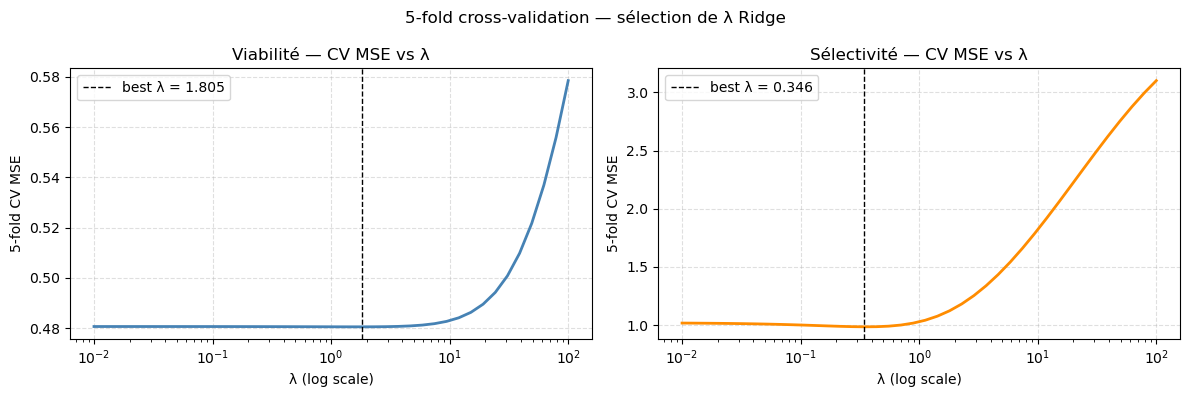

In [21]:
mask_viab = np.array(lambda1p > 0)
mask_sel  = np.array(n2 > 0)

X_viab = X_bias[mask_viab];  y_viab_m = np.array(y_viab)[mask_viab]
X_sel  = X_bias[mask_sel];   y_sel_m  = np.array(y_sel)[mask_sel]

K_FOLDS = 5
lambdas = np.logspace(-2, 2, 40)

kf = KFold(n_splits=K_FOLDS, shuffle=True, random_state=0)

cv_mse_viab = ridge_cv_mse(X_viab, y_viab_m, lambdas, kf)
cv_mse_sel  = ridge_cv_mse(X_sel,  y_sel_m,  lambdas, kf)

lam_best_viab = lambdas[np.argmin(cv_mse_viab)]
lam_best_sel  = lambdas[np.argmin(cv_mse_sel)]
print(f'Best λ viabilité   : {lam_best_viab:.3f}')
print(f'Best λ sélectivité : {lam_best_sel:.3f}')

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, mse, lam_best, label, color in [
    (axes[0], cv_mse_viab, lam_best_viab, 'Viabilité',   'steelblue'),
    (axes[1], cv_mse_sel,  lam_best_sel,  'Sélectivité', 'darkorange'),
]:
    ax.semilogx(lambdas, mse, color=color, lw=2)
    ax.axvline(lam_best, color='k', linestyle='--', lw=1,
               label=f'best λ = {lam_best:.3f}')
    ax.set_xlabel('λ (log scale)', fontsize=14)
    ax.set_ylabel(f'{K_FOLDS}-fold CV MSE', fontsize=14)
    ax.set_title(f'{label} — CV MSE vs λ')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylim(bottom=0)
    ax.tick_params(labelsize=12)
    ax.legend(fontsize=11, borderaxespad=0.3)

plt.suptitle(f'{K_FOLDS}-fold cross-validation — sélection de λ Ridge', fontsize=12)
plt.tight_layout()
plt.show()


In [22]:
viability_weights_hat   = fit_weights_ridge(X_viab, y_viab_m, T_viab, lam=lam_best_viab)
selectivity_weights_hat = fit_weights_ridge(X_sel,  y_sel_m,  T_sel,  lam=lam_best_sel)

v_gt = calculate_scores(sequences, viability_weights)
s_gt = calculate_scores(sequences, selectivity_weights)

print(f'               Ridge (CV λ_viab={lam_best_viab:.2f}, λ_sel={lam_best_sel:.2f})')
for label, w_hat, gt in [
    ('Viabilité   — r(scores)', viability_weights_hat,   v_gt),
    ('Sélectivité — r(scores)', selectivity_weights_hat, s_gt),
]:
    h = calculate_scores(sequences, w_hat)
    print(f'  {label}:  {pearson(h, gt):.4f}')


               Ridge (CV λ_viab=1.80, λ_sel=0.35)
  Viabilité   — r(scores):  0.9898
  Sélectivité — r(scores):  0.9122


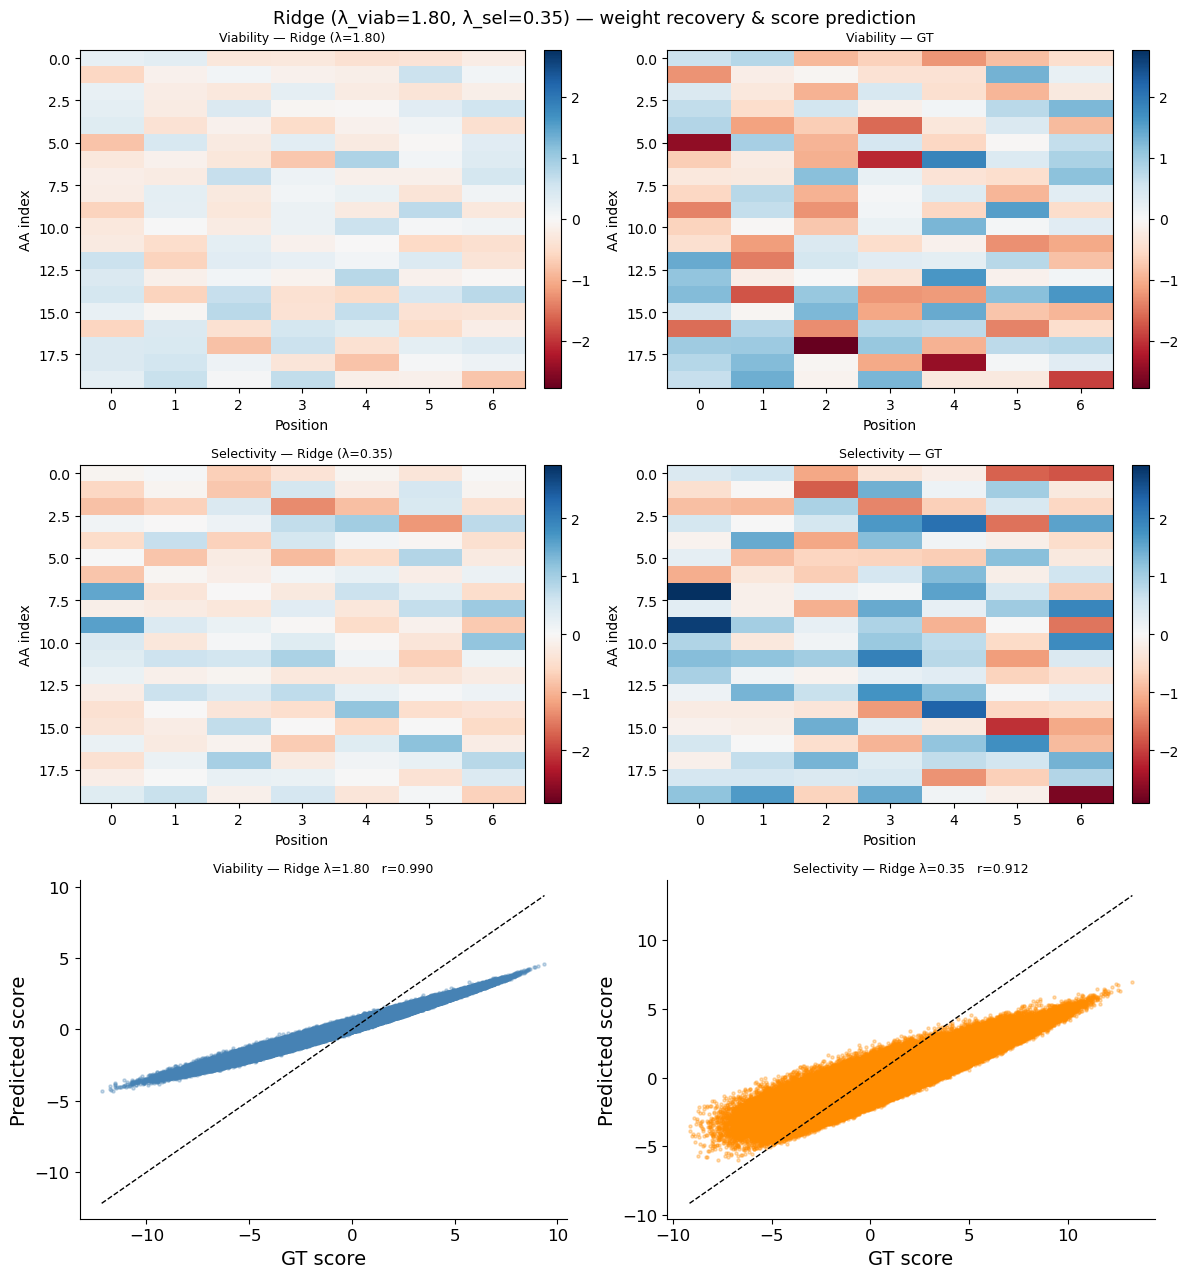

In [29]:
fig, axes = plt.subplots(3, 2, figsize=(12, 13))

# ── Rows 0-1: Ridge | GT weight matrices ─────────────────────────────────────
for row, (w_gt_m, w_hat, label, lam_row) in enumerate([
    (viability_weights,   viability_weights_hat,   'Viability',   lam_best_viab),
    (selectivity_weights, selectivity_weights_hat, 'Selectivity', lam_best_sel),
]):
    vmax = float(jnp.abs(jnp.stack([w_gt_m, w_hat])).max())
    for col, (data, title) in enumerate([
        (w_hat,  f'{label} — Ridge (λ={lam_row:.2f})'),
        (w_gt_m, f'{label} — GT'),
    ]):
        ax = axes[row, col]
        im = ax.imshow(np.array(data), cmap='RdBu', aspect='auto',
                       vmin=-vmax, vmax=vmax)
        ax.set_title(title, fontsize=9)
        ax.set_xlabel('Position'); ax.set_ylabel('AA index')
        ax.set_xticks(range(num_positions))
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# ── Row 2: score scatter Ridge vs GT ─────────────────────────────────────────
for col, (gt, w_hat, label, color, lam_row) in enumerate([
    (v_gt, viability_weights_hat,   'Viability',   'steelblue',  lam_best_viab),
    (s_gt, selectivity_weights_hat, 'Selectivity', 'darkorange', lam_best_sel),
]):
    ax = axes[2, col]
    hat = calculate_scores(sequences, w_hat)
    ax.scatter(gt, hat, alpha=0.3, s=5, color=color)
    lo = float(min(gt.min(), hat.min()))
    hi = float(max(gt.max(), hat.max()))
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
    r_val = pearson(gt, hat)
    ax.set_title(f'{label} — Ridge λ={lam_row:.2f}   r={r_val:.3f}', fontsize=9)
    ax.set_xlabel('GT score', fontsize=14); ax.set_ylabel('Predicted score', fontsize=14)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=12)

plt.suptitle(
    f'Ridge (λ_viab={lam_best_viab:.2f}, λ_sel={lam_best_sel:.2f}) — weight recovery & score prediction',
    fontsize=13)
plt.tight_layout()
plt.show()


  Top-%    Precision@k   (random baseline = top-%)
  ──────────────────────────────────────────────────
  Top   1%      0.659          (baseline: 0.010)
  Top   5%      0.724          (baseline: 0.050)
  Top  10%      0.757          (baseline: 0.100)
  Top  20%      0.794          (baseline: 0.200)


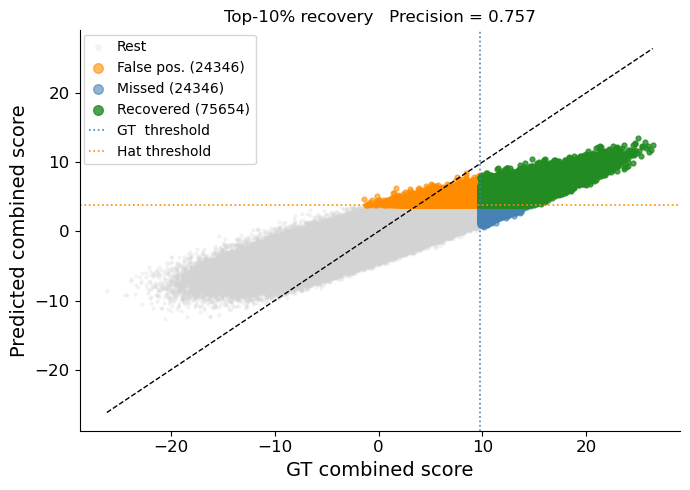

In [28]:
v_hat = calculate_scores(sequences, viability_weights_hat)
s_hat = calculate_scores(sequences, selectivity_weights_hat)

combined_hat = v_hat / T_viab + s_hat / T_sel   # predicted ranking

fracs = [0.01, 0.05, 0.10, 0.20]
print(f'  Top-%    Precision@k   (random baseline = top-%)')
print(f'  ──────────────────────────────────────────────────')
for frac in fracs:
    p = precision_at_k(combined_scores, combined_hat, k_frac=frac)
    print(f'  Top {int(frac*100):3d}%      {p:.3f}          (baseline: {frac:.3f})')

# ── Visual: rank scatter + top-10% highlight ─────────────────────────────────
k10      = int(num_sequences * 0.10)
top_gt   = set(np.argsort(-np.array(combined_scores))[:k10])
top_hat  = set(np.argsort(-np.array(combined_hat))[:k10])
both     = np.array(sorted(top_gt & top_hat))      # recovered
only_gt  = np.array(sorted(top_gt  - top_hat))     # missed
only_hat = np.array(sorted(top_hat - top_gt))      # false positives
rest     = np.array(sorted(set(range(num_sequences)) - top_gt - top_hat))

cgt  = np.array(combined_scores)
chat = np.array(combined_hat)

fig, ax   = plt.subplots(1, 1, figsize=(7, 5))

# GT score vs predicted score, coloured by category
ax.scatter(cgt[rest],     chat[rest],     s=4,  alpha=0.2, color='lightgray',   label='Rest')
ax.scatter(cgt[only_hat], chat[only_hat], s=12, alpha=0.6, color='darkorange',  label=f'False pos. ({len(only_hat)})')
ax.scatter(cgt[only_gt],  chat[only_gt],  s=12, alpha=0.6, color='steelblue',   label=f'Missed ({len(only_gt)})')
ax.scatter(cgt[both],     chat[both],     s=12, alpha=0.8, color='forestgreen', label=f'Recovered ({len(both)})')
lo = float(min(cgt.min(), chat.min()))
hi = float(max(cgt.max(), chat.max()))
ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
# Thresholds
thr_gt  = float(np.sort(cgt)[-k10])
thr_hat = float(np.sort(chat)[-k10])
ax.axvline(thr_gt,  color='steelblue',  linestyle=':', lw=1.2, label=f'GT  threshold')
ax.axhline(thr_hat, color='darkorange', linestyle=':', lw=1.2, label=f'Hat threshold')
ax.set_xlabel('GT combined score', fontsize=14); ax.set_ylabel('Predicted combined score', fontsize=14)
ax.set_title(f'Top-10% recovery   Precision = {precision_at_k(combined_scores, combined_hat):.3f}')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(labelsize=12)
ax.legend(fontsize=10, markerscale=2, borderaxespad=0.3, borderpad=0.4, handlelength=1.2)



plt.tight_layout()
plt.show()

Maximum viability score is 8.199999809265137
epsilon=0.00  lambda_CV=8.859
epsilon=0.08  lambda_CV=8.859
epsilon=0.82  lambda_CV=14.384
epsilon=2.73  lambda_CV=100.000


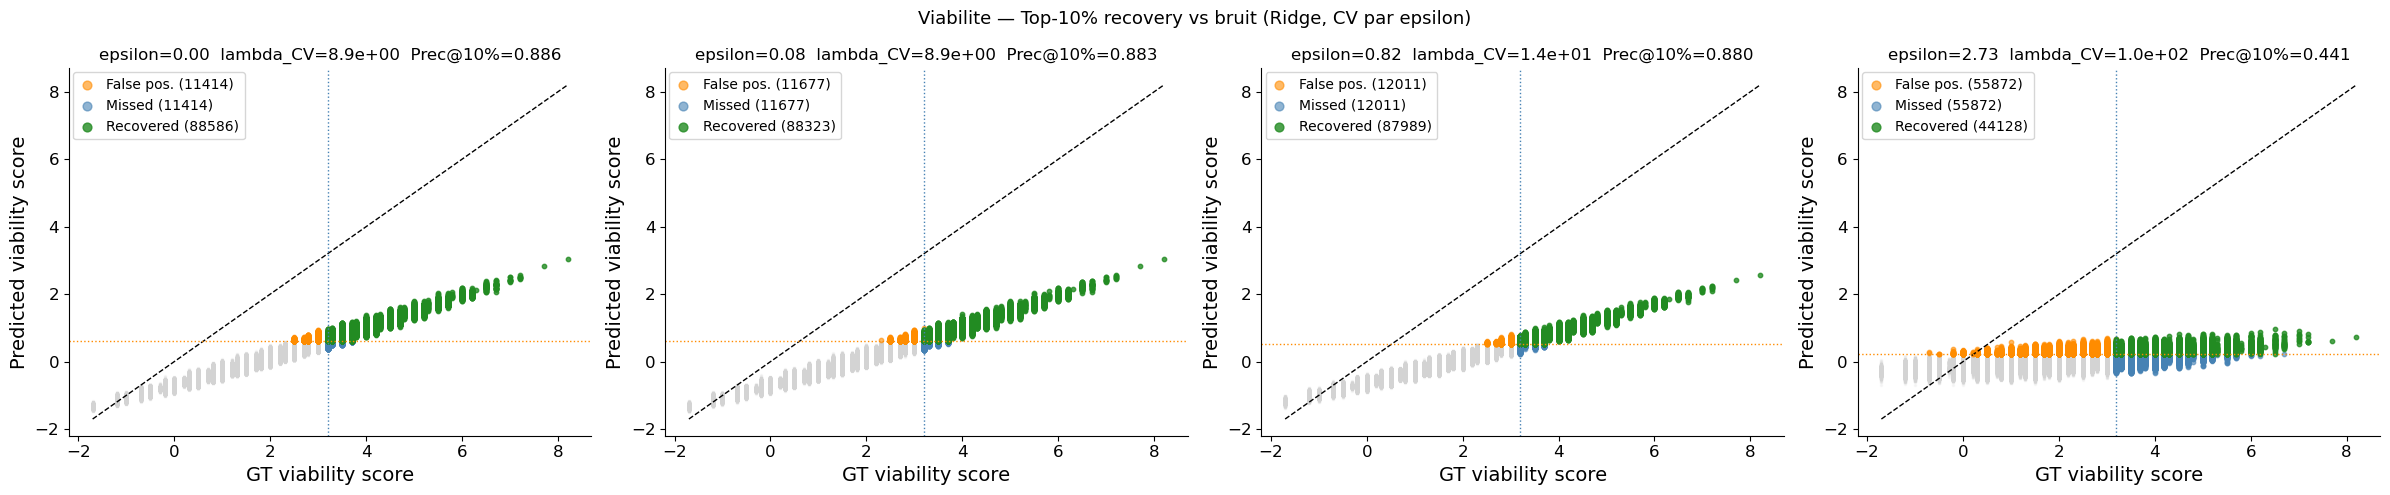

In [31]:
# Viability — top-10% recovery for 4 noise levels, CV re-run per epsilon (Ridge)
_eps_pc   = 0.5
v_gt_e    = np.array(calculate_scores(sequences, viability_weights_GT))
s_gt_e    = np.array(calculate_scores(sequences, selectivity_weights_GT))
max_vgt_e = float(v_gt_e.max())
print(f'Maximum viability score is {max_vgt_e}')
eps_viab_      = [0.0, max_vgt_e / 100, max_vgt_e / 10, max_vgt_e / 3]
eps_sel_fix    = 0.3
_lambdas_sweep = np.logspace(-2, 2, 20)
_kf_eps        = KFold(n_splits=5, shuffle=True, random_state=0)

fig, axes = plt.subplots(1, 4, figsize=(24, 5))
axes = axes.flatten()

for ax, eps in zip(axes, eps_viab_):
    _, _caps, lam1p_e, _n2 = protocol(
        n0, sequences, viability_weights_GT, selectivity_weights_GT,
        epsilon_viability=eps, epsilon_selectivity=eps_sel_fix, use_full_ngs=False,
    )
    n0_n      = n0 / jnp.sum(n0) * jnp.sum(lam1p_e)
    y_v       = np.array(jnp.log((lam1p_e + _eps_pc) / (n0_n + _eps_pc)))
    _mask     = np.array(lam1p_e > 0)
    _cv_mse_v = ridge_cv_mse(X_bias[_mask], y_v[_mask], _lambdas_sweep, _kf_eps)
    _lam_eps  = _lambdas_sweep[np.argmin(_cv_mse_v)]
    print(f'epsilon={eps:.2f}  lambda_CV={_lam_eps:.3f}', flush=True)

    _w  = fit_weights_ridge(X_bias[_mask], y_v[_mask], T_viab, lam=_lam_eps)
    _vh = np.array(calculate_scores(sequences, _w))

    k10        = int(num_sequences * 0.10)
    top_gt_v   = set(np.argsort(-v_gt_e)[:k10])
    top_hat_v  = set(np.argsort(-_vh)[:k10])
    both_v     = np.array(sorted(top_gt_v & top_hat_v))
    only_gt_v  = np.array(sorted(top_gt_v  - top_hat_v))
    only_hat_v = np.array(sorted(top_hat_v - top_gt_v))
    rest_v     = np.array(sorted(set(range(num_sequences)) - top_gt_v - top_hat_v))

    ax.scatter(v_gt_e[rest_v],     _vh[rest_v],     s=2,  alpha=0.15, color='lightgray')
    ax.scatter(v_gt_e[only_hat_v], _vh[only_hat_v], s=10, alpha=0.6,  color='darkorange',
               label=f'False pos. ({len(only_hat_v)})')
    ax.scatter(v_gt_e[only_gt_v],  _vh[only_gt_v],  s=10, alpha=0.6,  color='steelblue',
               label=f'Missed ({len(only_gt_v)})')
    ax.scatter(v_gt_e[both_v],     _vh[both_v],     s=10, alpha=0.8,  color='forestgreen',
               label=f'Recovered ({len(both_v)})')
    lo, hi = v_gt_e.min(), v_gt_e.max()
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
    ax.axvline(np.sort(v_gt_e)[-k10], color='steelblue',  linestyle=':', lw=1)
    ax.axhline(np.sort(_vh)[-k10],    color='darkorange', linestyle=':', lw=1)
    p10 = precision_at_k(v_gt_e, _vh, k_frac=0.10)
    ax.set_xlabel('GT viability score', fontsize=14)
    ax.set_ylabel('Predicted viability score', fontsize=14)
    ax.set_title(f'epsilon={eps:.2f}  lambda_CV={_lam_eps:.1e}  Prec@10%={p10:.3f}')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=12)
    ax.legend(fontsize=10, markerscale=2, borderaxespad=0.3, borderpad=0.4, handlelength=1.2)

plt.suptitle('Viabilite — Top-10% recovery vs bruit (Ridge, CV par epsilon)', fontsize=13)
plt.tight_layout(); plt.show()


maximum value for selectivity scores is 5.0
epsilon=0.00  lambda_CV=1.274
epsilon=0.05  lambda_CV=2.069
epsilon=0.50  lambda_CV=3.360
epsilon=1.67  lambda_CV=23.357


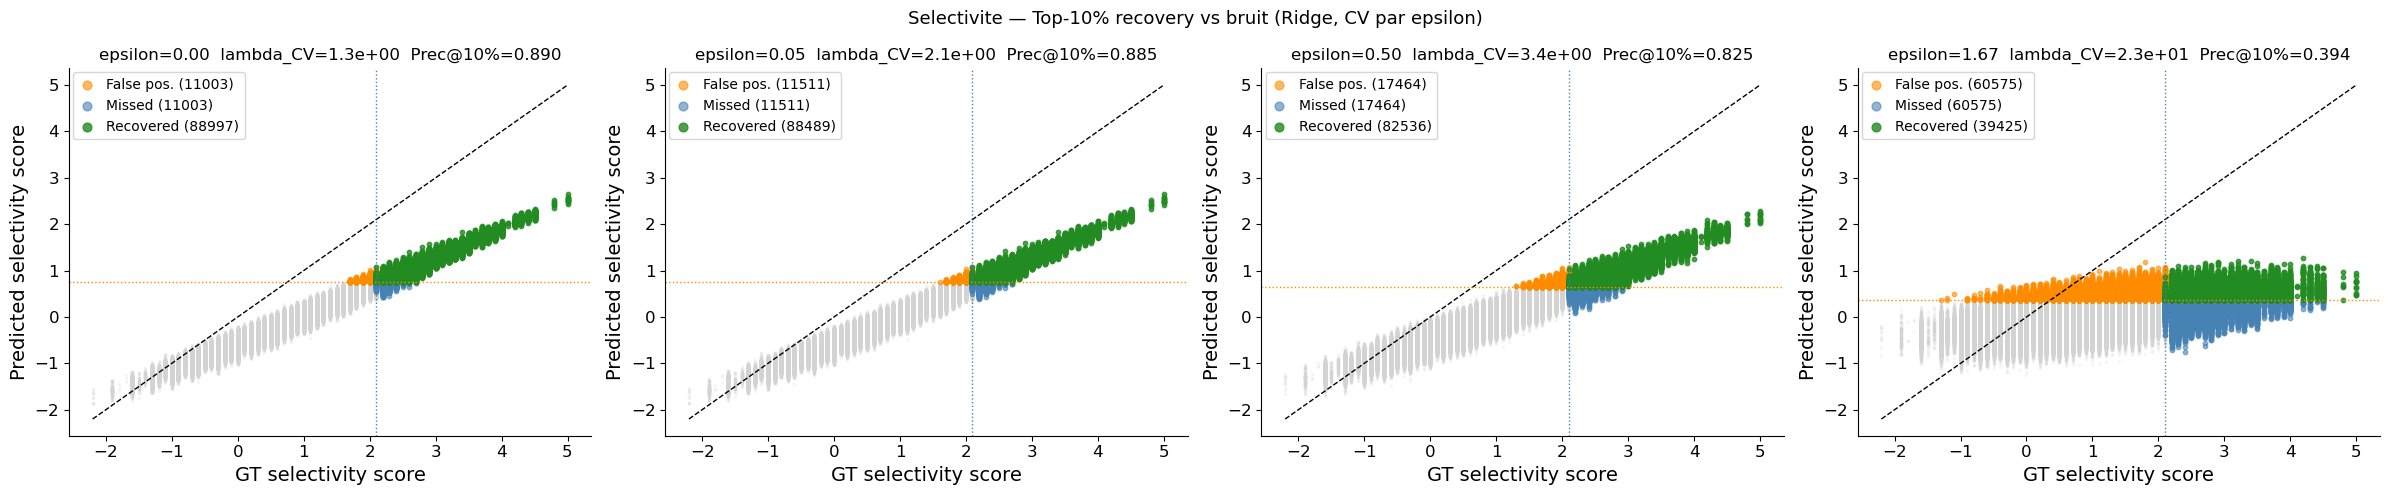

In [32]:
# Selectivity — top-10% recovery for 4 noise levels, CV re-run per epsilon (Ridge)
max_sgt_e    = float(s_gt_e.max())
print(f'maximum value for selectivity scores is {max_sgt_e}')
eps_sel_     = [0.0, max_sgt_e / 100, max_sgt_e / 10, max_sgt_e / 3]
eps_viab_fix = 0.3

fig, axes = plt.subplots(1, 4, figsize=(24, 5))
axes = axes.flatten()

for ax, eps in zip(axes, eps_sel_):
    _, _caps, lam1p_e2, n2_e2 = protocol(
        n0, sequences, viability_weights_GT, selectivity_weights_GT,
        epsilon_viability=eps_viab_fix, epsilon_selectivity=eps, use_full_ngs=False,
    )
    l1p_n      = lam1p_e2 / jnp.sum(lam1p_e2) * jnp.sum(n2_e2)
    y_s        = np.array(jnp.log((n2_e2 + _eps_pc) / (l1p_n + _eps_pc)))
    _mask      = np.array(n2_e2 > 0)
    _cv_mse_s  = ridge_cv_mse(X_bias[_mask], y_s[_mask], _lambdas_sweep, _kf_eps)
    _lam_eps_s = _lambdas_sweep[np.argmin(_cv_mse_s)]
    print(f'epsilon={eps:.2f}  lambda_CV={_lam_eps_s:.3f}', flush=True)

    _ws = fit_weights_ridge(X_bias[_mask], y_s[_mask], T_sel, lam=_lam_eps_s)
    _sh = np.array(calculate_scores(sequences, _ws))

    k10        = int(num_sequences * 0.10)
    top_gt_s   = set(np.argsort(-s_gt_e)[:k10])
    top_hat_s  = set(np.argsort(-_sh)[:k10])
    both_s     = np.array(sorted(top_gt_s & top_hat_s))
    only_gt_s  = np.array(sorted(top_gt_s  - top_hat_s))
    only_hat_s = np.array(sorted(top_hat_s - top_gt_s))
    rest_s     = np.array(sorted(set(range(num_sequences)) - top_gt_s - top_hat_s))

    ax.scatter(s_gt_e[rest_s],     _sh[rest_s],     s=2,  alpha=0.15, color='lightgray')
    ax.scatter(s_gt_e[only_hat_s], _sh[only_hat_s], s=10, alpha=0.6,  color='darkorange',
               label=f'False pos. ({len(only_hat_s)})')
    ax.scatter(s_gt_e[only_gt_s],  _sh[only_gt_s],  s=10, alpha=0.6,  color='steelblue',
               label=f'Missed ({len(only_gt_s)})')
    ax.scatter(s_gt_e[both_s],     _sh[both_s],     s=10, alpha=0.8,  color='forestgreen',
               label=f'Recovered ({len(both_s)})')
    lo, hi = s_gt_e.min(), s_gt_e.max()
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
    ax.axvline(np.sort(s_gt_e)[-k10], color='steelblue',  linestyle=':', lw=1)
    ax.axhline(np.sort(_sh)[-k10],    color='darkorange', linestyle=':', lw=1)
    p10 = precision_at_k(s_gt_e, _sh, k_frac=0.10)
    ax.set_xlabel('GT selectivity score', fontsize=14)
    ax.set_ylabel('Predicted selectivity score', fontsize=14)
    ax.set_title(f'epsilon={eps:.2f}  lambda_CV={_lam_eps_s:.1e}  Prec@10%={p10:.3f}')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=12)
    ax.legend(fontsize=10, markerscale=2, borderaxespad=0.3, borderpad=0.4, handlelength=1.2)

plt.suptitle('Selectivite — Top-10% recovery vs bruit (Ridge, CV par epsilon)', fontsize=13)
plt.tight_layout(); plt.show()
